# Vamos criar um modelo predito de machine learning para prever o score de crédito do cliente
<p> Um resumo do que veremos aqui:<br>
    - Analise Exploratória e Gráficos<br>
    - Tratamento de dados missing <br>
    - Tratamento de outliers <br>
    - OneHotEncoding <br>
    - Engenharia de Atributos <br>
    - Tratamento de dados <br>
    - Normalização de dados <br>
    - Criação, teste e validação de um modelo de machine learning

## IMPORTAÇÃO DAS BIBLIOTECAS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import MinMaxScaler 
from sklearn.preprocessing import LabelEncoder 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score 

## CARREGAMENTO DOS DADOS

In [2]:
df = pd.read_excel("dados_credito.xlsx")

print("Dimensão inicial do dataset:", df.shape)
df.head()

Dimensão inicial do dataset: (10476, 17)


,CODIGO_CLIENTE,UF,IDADE,ESCOLARIDADE,ESTADO_CIVIL,QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,SCORE
0,1,SP,19,Superior Cursando,Solteiro,0,Não,0,0,Não,0,8,Sim,1800,0,0,12.000000
1,2,MG,23,Superior Completo,Solteiro,1,Não,0,0,Não,0,9,Não,4800,1,50000,18.000000
2,3,SC,25,Segundo Grau Completo,Casado,0,Sim,1,220000,Não,0,18,Sim,2200,2,30000,23.000000
3,4,PR,27,Superior Cursando,Casado,1,Sim,0,0,Não,0,22,Não,3900,0,0,28.666667
4,5,RJ,28,Superior Completo,Divorciado,2,Não,1,370000,Não,0,30,Sim,NaN,1,35000,34.166667


## INSPEÇÃO INICIAL 

In [3]:
df.info()
df.describe(include='all').T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10476 entries, 0 to 10475
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CODIGO_CLIENTE              10476 non-null  int64  
 1   UF                          10476 non-null  object 
 2   IDADE                       10476 non-null  int64  
 3   ESCOLARIDADE                10476 non-null  object 
 4   ESTADO_CIVIL                10476 non-null  object 
 5   QT_FILHOS                   10476 non-null  int64  
 6   CASA_PROPRIA                10476 non-null  object 
 7   QT_IMOVEIS                  10476 non-null  int64  
 8   VL_IMOVEIS                  10476 non-null  int64  
 9   OUTRA_RENDA                 10476 non-null  object 
 10  OUTRA_RENDA_VALOR           10476 non-null  int64  
 11  TEMPO_ULTIMO_EMPREGO_MESES  10476 non-null  int64  
 12  TRABALHANDO_ATUALMENTE      10476 non-null  object 
 13  ULTIMO_SALARIO              104

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CODIGO_CLIENTE,10476.0,NaN,NaN,NaN,5238.5,3024.305044,1.0,2619.75,5238.5,7857.25,10476.0
UF,10476,5,RJ,2916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IDADE,10476.0,NaN,NaN,NaN,41.054124,13.878162,19.0,28.0,42.0,53.0,65.0
ESCOLARIDADE,10476,3,Superior Completo,3672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ESTADO_CIVIL,10476,4,Casado,4716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
QT_FILHOS,10476.0,NaN,NaN,NaN,1.122566,1.113537,0.0,0.0,1.0,2.0,42.0
CASA_PROPRIA,10476,2,Não,5724,NaN,NaN,NaN,NaN,NaN,NaN,NaN
QT_IMOVEIS,10476.0,NaN,NaN,NaN,0.847079,0.957374,0.0,0.0,1.0,1.0,3.0
VL_IMOVEIS,10476.0,NaN,NaN,NaN,238453.608247,265843.934416,0.0,0.0,185000.0,370000.0,900000.0
OUTRA_RENDA,10476,2,Não,8352,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## TRATAMENTO DE DADOS FALTANTES E INCONSISTÊNCIAS

In [4]:
df.isnull().sum()

CODIGO_CLIENTE                0
UF                            0
IDADE                         0
ESCOLARIDADE                  0
ESTADO_CIVIL                  0
QT_FILHOS                     0
CASA_PROPRIA                  0
QT_IMOVEIS                    0
VL_IMOVEIS                    0
OUTRA_RENDA                   0
OUTRA_RENDA_VALOR             0
TEMPO_ULTIMO_EMPREGO_MESES    0
TRABALHANDO_ATUALMENTE        0
ULTIMO_SALARIO                2
QT_CARROS                     0
VALOR_TABELA_CARROS           0
SCORE                         0
dtype: int64

In [5]:
df.groupby(['ULTIMO_SALARIO']).size()

ULTIMO_SALARIO
1800         846
2200         792
3100         792
3900         792
4500         468
4800         792
5300         522
6100         522
6800         611
9000         522
9800         468
11500        790
13000        522
15000        522
17500        522
18300        522
22000        468
SEM DADOS      1
dtype: int64

In [6]:
df.replace('SEM DADOS',np.nan, inplace = True)

C:\Users\Bruno Nava Mainardi\AppData\Local\Temp\ipykernel_8920\3887586098.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('SEM DADOS',np.nan, inplace = True)


In [7]:
df['ULTIMO_SALARIO'] = df['ULTIMO_SALARIO'].fillna((df['ULTIMO_SALARIO'].median()))

In [8]:
df['ULTIMO_SALARIO'] = df['ULTIMO_SALARIO'].astype(np.float64)
df['VL_IMOVEIS'] = df['VL_IMOVEIS'].astype(np.float64)
df['OUTRA_RENDA_VALOR'] = df['OUTRA_RENDA_VALOR'].astype(np.float64)
df['VALOR_TABELA_CARROS'] = df['VALOR_TABELA_CARROS'].astype(np.float64)

In [9]:
df.groupby(['QT_FILHOS']).size()

QT_FILHOS
0     3329
1     3726
2     2303
3     1116
38       1
42       1
dtype: int64

In [10]:
df.loc[df['QT_FILHOS'] > 3, 'QT_FILHOS'] = 3

In [11]:
df.groupby(['OUTRA_RENDA_VALOR']).size()

OUTRA_RENDA_VALOR
0.0       8352
2400.0     468
3000.0     612
3200.0     522
4000.0     522
dtype: int64

In [12]:
df.groupby(['VALOR_TABELA_CARROS']).size()

VALOR_TABELA_CARROS
0.0         3762
28000.0      468
30000.0      792
35000.0      792
40000.0      792
48000.0      522
50000.0     1314
70000.0      522
80000.0      522
150000.0     468
180000.0     522
dtype: int64

In [13]:
df.groupby(['QT_IMOVEIS']).size()

QT_IMOVEIS
0    4680
1    3762
2     990
3    1044
dtype: int64

In [14]:
df.isnull().sum()

CODIGO_CLIENTE                0
UF                            0
IDADE                         0
ESCOLARIDADE                  0
ESTADO_CIVIL                  0
QT_FILHOS                     0
CASA_PROPRIA                  0
QT_IMOVEIS                    0
VL_IMOVEIS                    0
OUTRA_RENDA                   0
OUTRA_RENDA_VALOR             0
TEMPO_ULTIMO_EMPREGO_MESES    0
TRABALHANDO_ATUALMENTE        0
ULTIMO_SALARIO                0
QT_CARROS                     0
VALOR_TABELA_CARROS           0
SCORE                         0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

## ANÁLISE EXPLORATÓRIA (EDA)

In [16]:
variaveis_numericas = []
for i in df.columns[0:16].tolist():
        if df.dtypes[i] == 'int64' or df.dtypes[i] == 'float64':            
            print(i, ':' , df.dtypes[i]) 
            variaveis_numericas.append(i)

CODIGO_CLIENTE : int64
IDADE : int64
QT_FILHOS : int64
QT_IMOVEIS : int64
VL_IMOVEIS : float64
OUTRA_RENDA_VALOR : float64
TEMPO_ULTIMO_EMPREGO_MESES : int64
ULTIMO_SALARIO : float64
QT_CARROS : int64
VALOR_TABELA_CARROS : float64


In [17]:
variaveis_categoricas = []
for i in df.columns[0:48].tolist():
        if df.dtypes[i] == 'object' or df.dtypes[i] == 'category':            
            print(i, ':' , df.dtypes[i]) 
            variaveis_categoricas.append(i)           

UF : object
ESCOLARIDADE : object
ESTADO_CIVIL : object
CASA_PROPRIA : object
OUTRA_RENDA : object
TRABALHANDO_ATUALMENTE : object


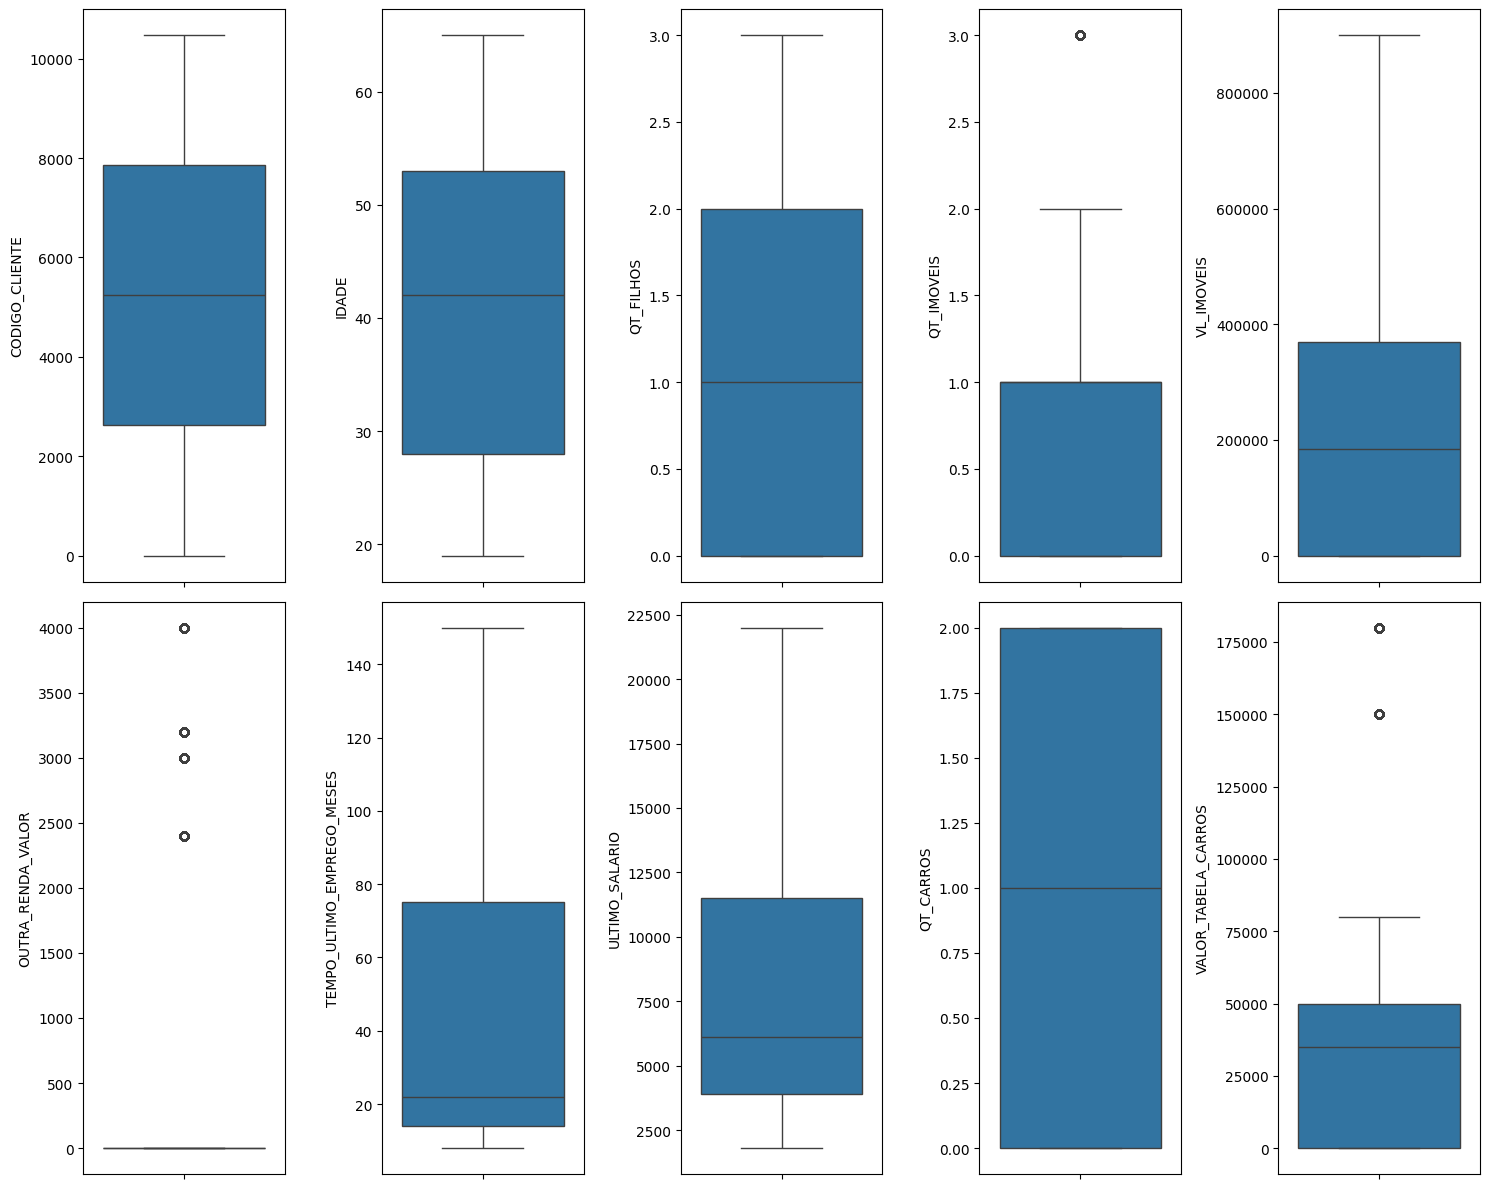

In [18]:
plt.rcParams["figure.figsize"] = [15.00, 12.00]
plt.rcParams["figure.autolayout"] = True

f, axes = plt.subplots(2, 5) 

linha = 0
coluna = 0

for i in variaveis_numericas:
    sns.boxplot(data = df, y=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 5:
        linha += 1
        coluna = 0            

plt.show()

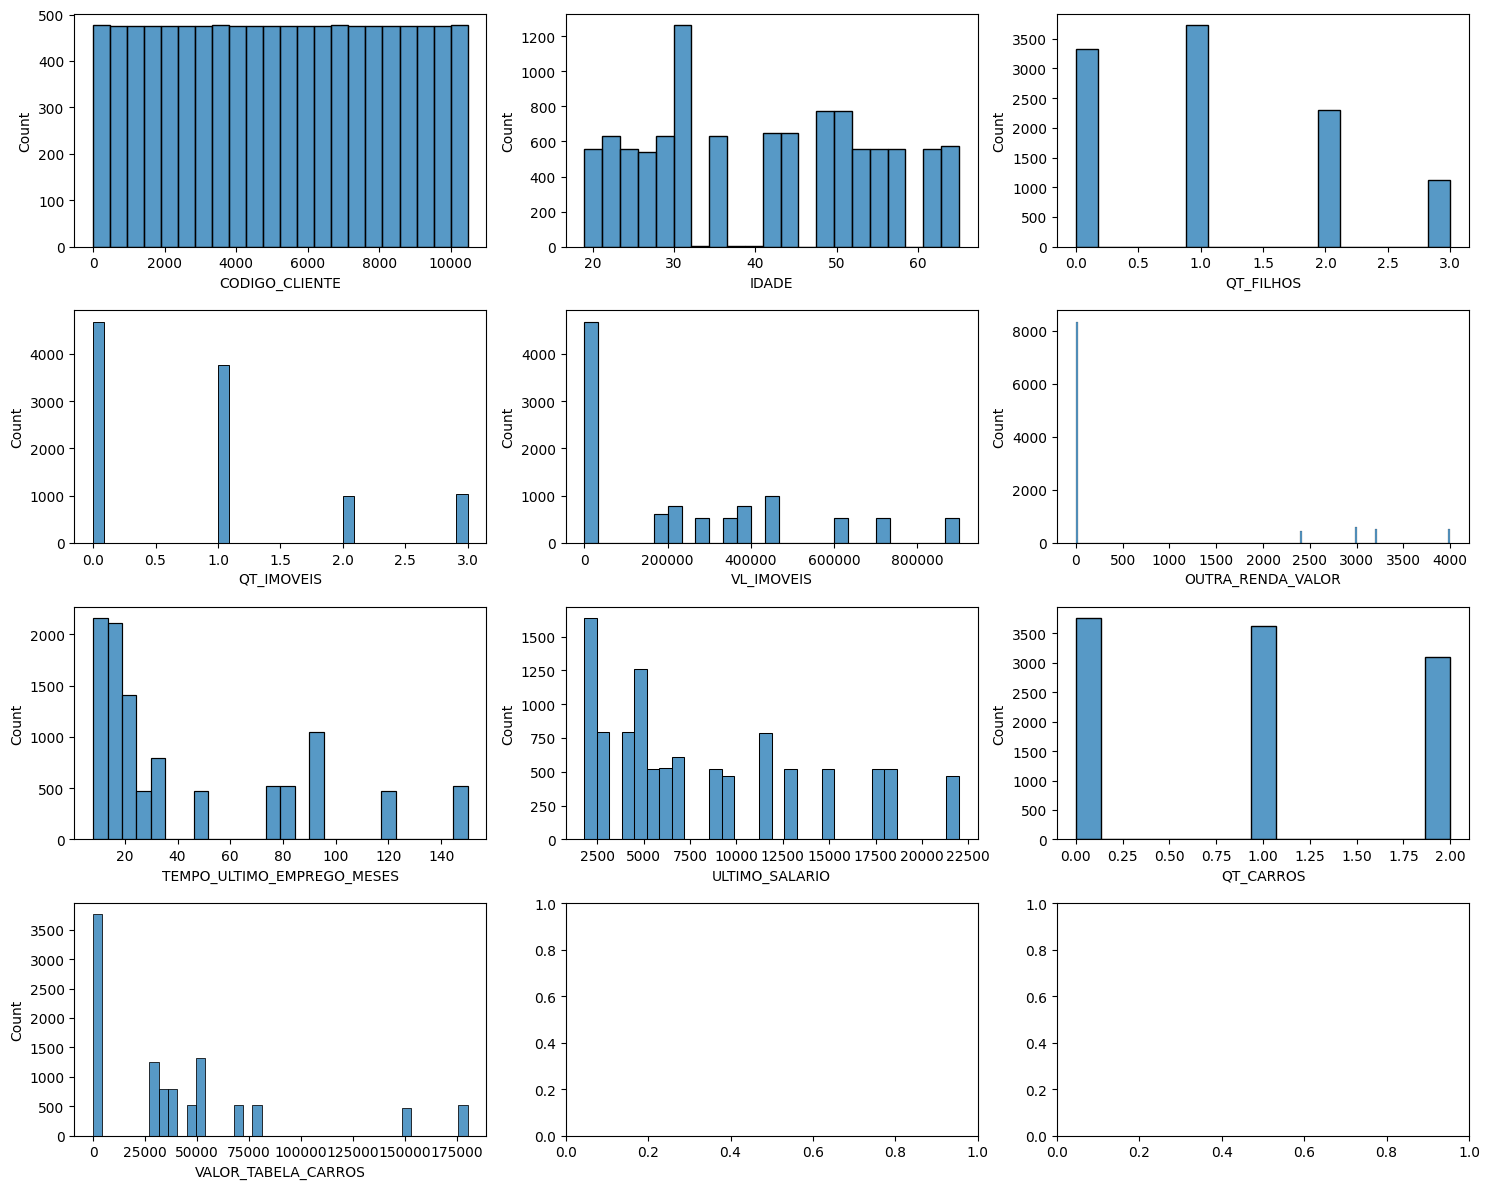

In [19]:
plt.rcParams["figure.figsize"] = [15.00, 12.00]
plt.rcParams["figure.autolayout"] = True

f, axes = plt.subplots(4, 3) 

linha = 0
coluna = 0

for i in variaveis_numericas:
    sns.histplot(data = df, x=i, ax=axes[linha][coluna])    
    coluna += 1
    if coluna == 3:
        linha += 1
        coluna = 0            

plt.show()

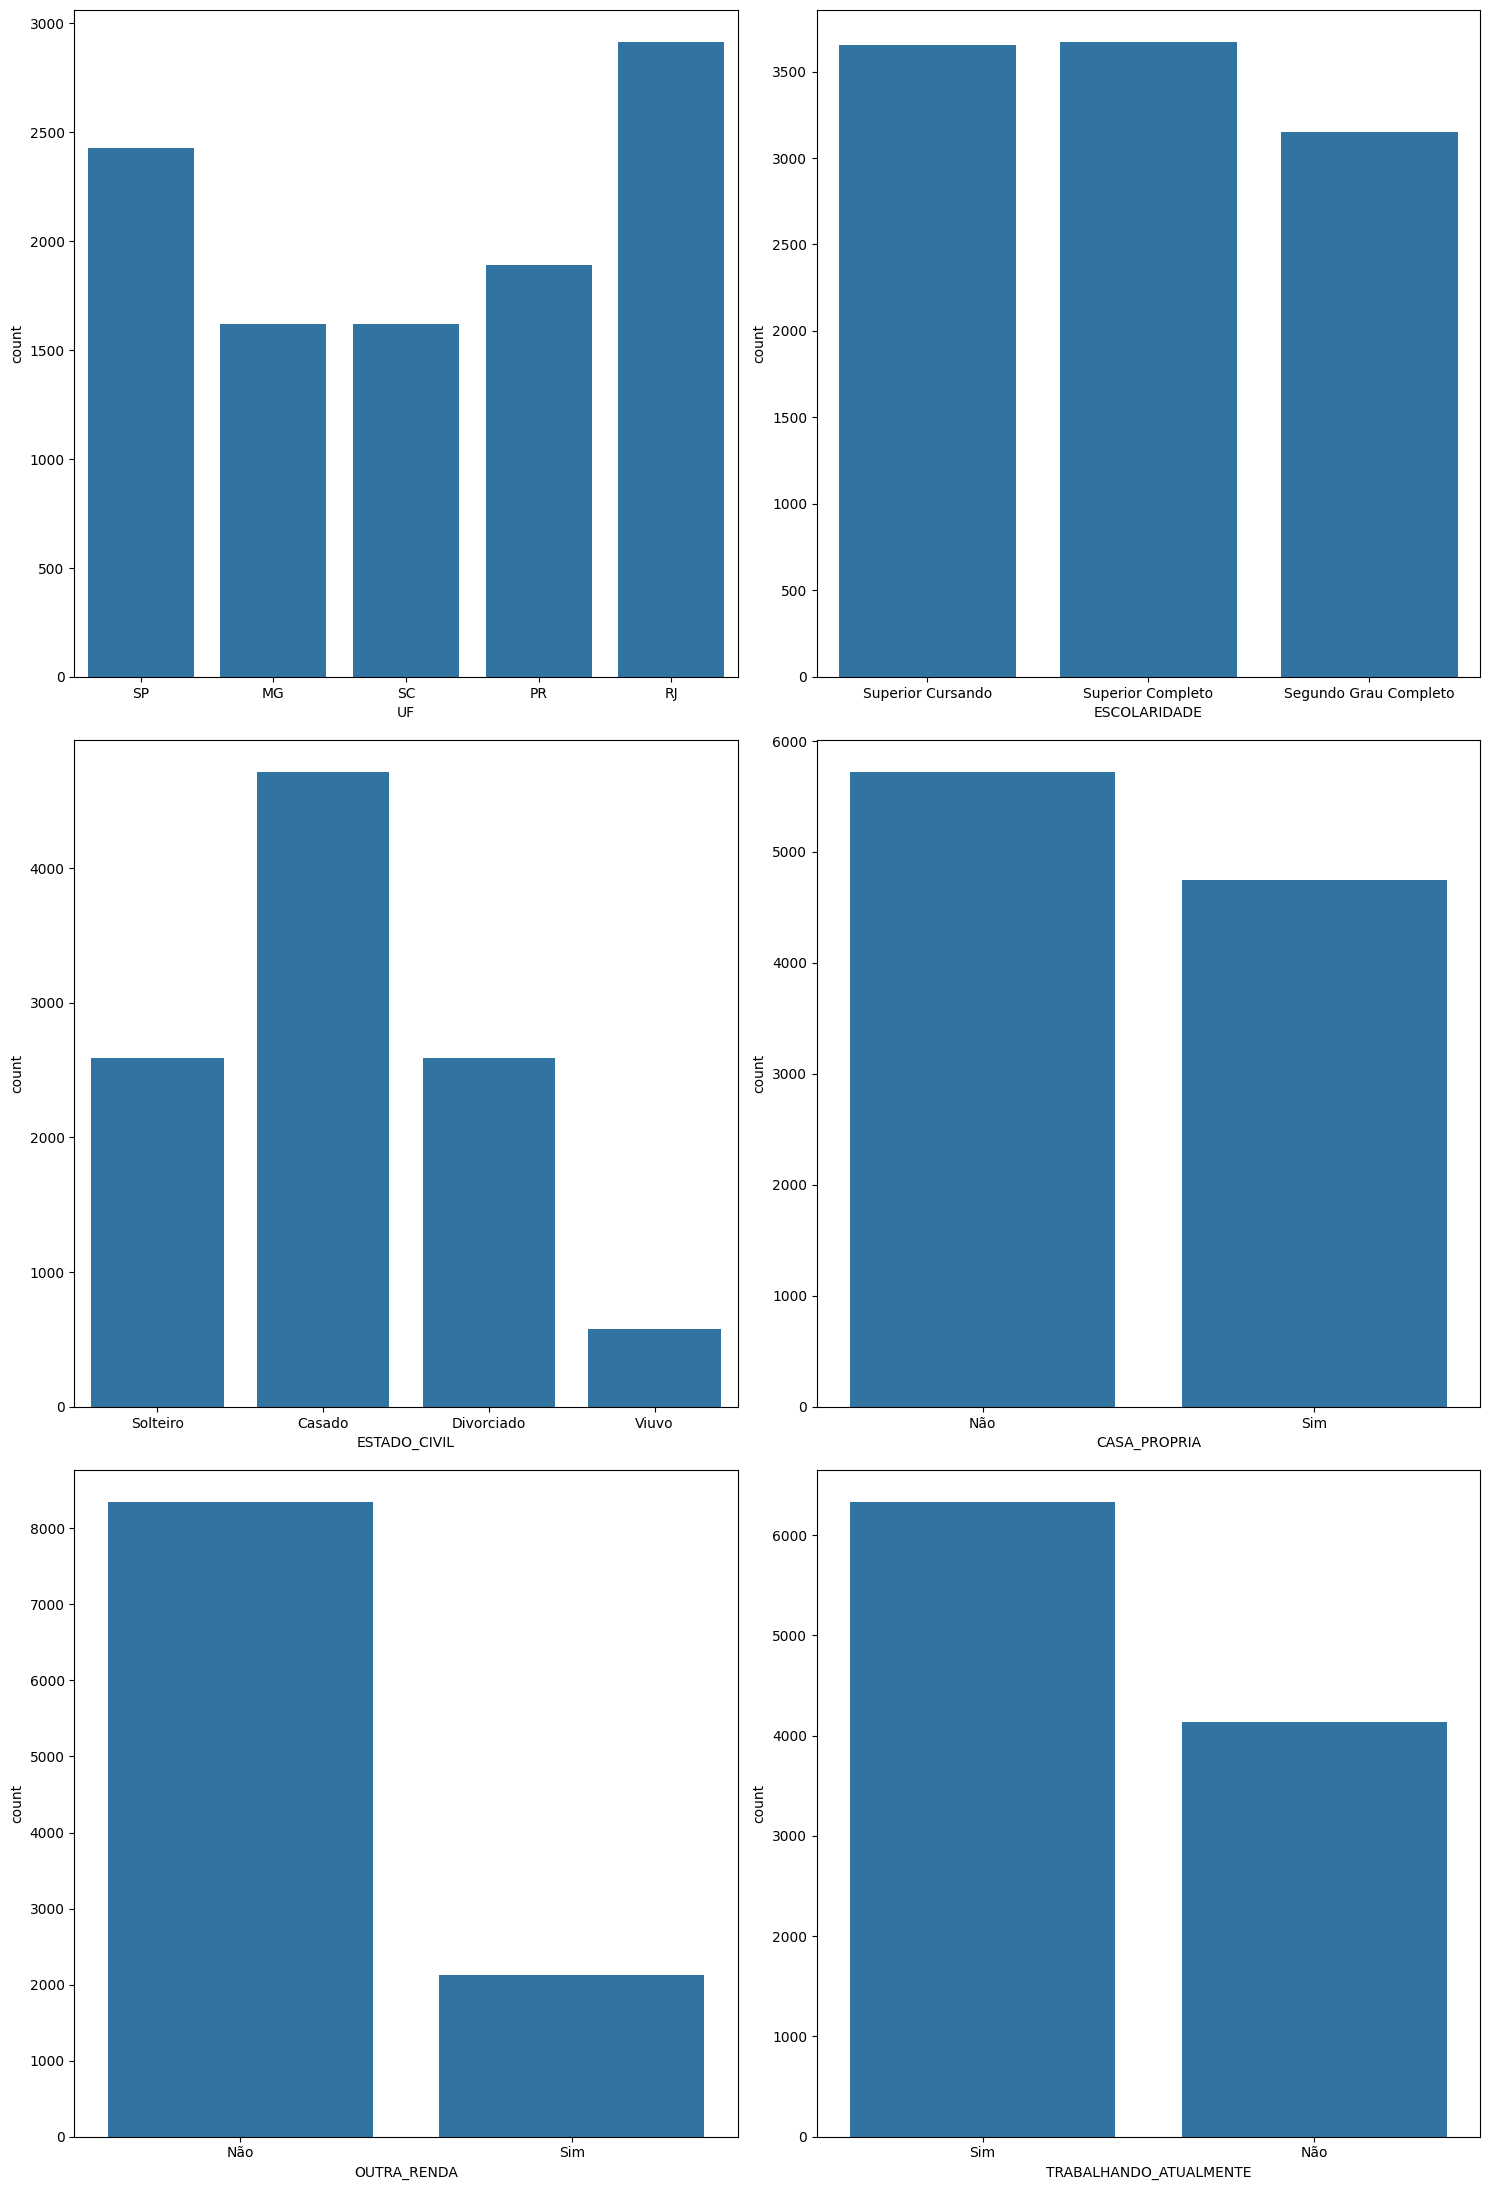

In [20]:

plt.rcParams["figure.figsize"] = [15.00, 22.00]
plt.rcParams["figure.autolayout"] = True


f, axes = plt.subplots(3, 2) 

linha = 0
coluna = 0

for i in variaveis_categoricas:    
    sns.countplot(data = df, x=i, ax=axes[linha][coluna])
    
    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0            

plt.show()



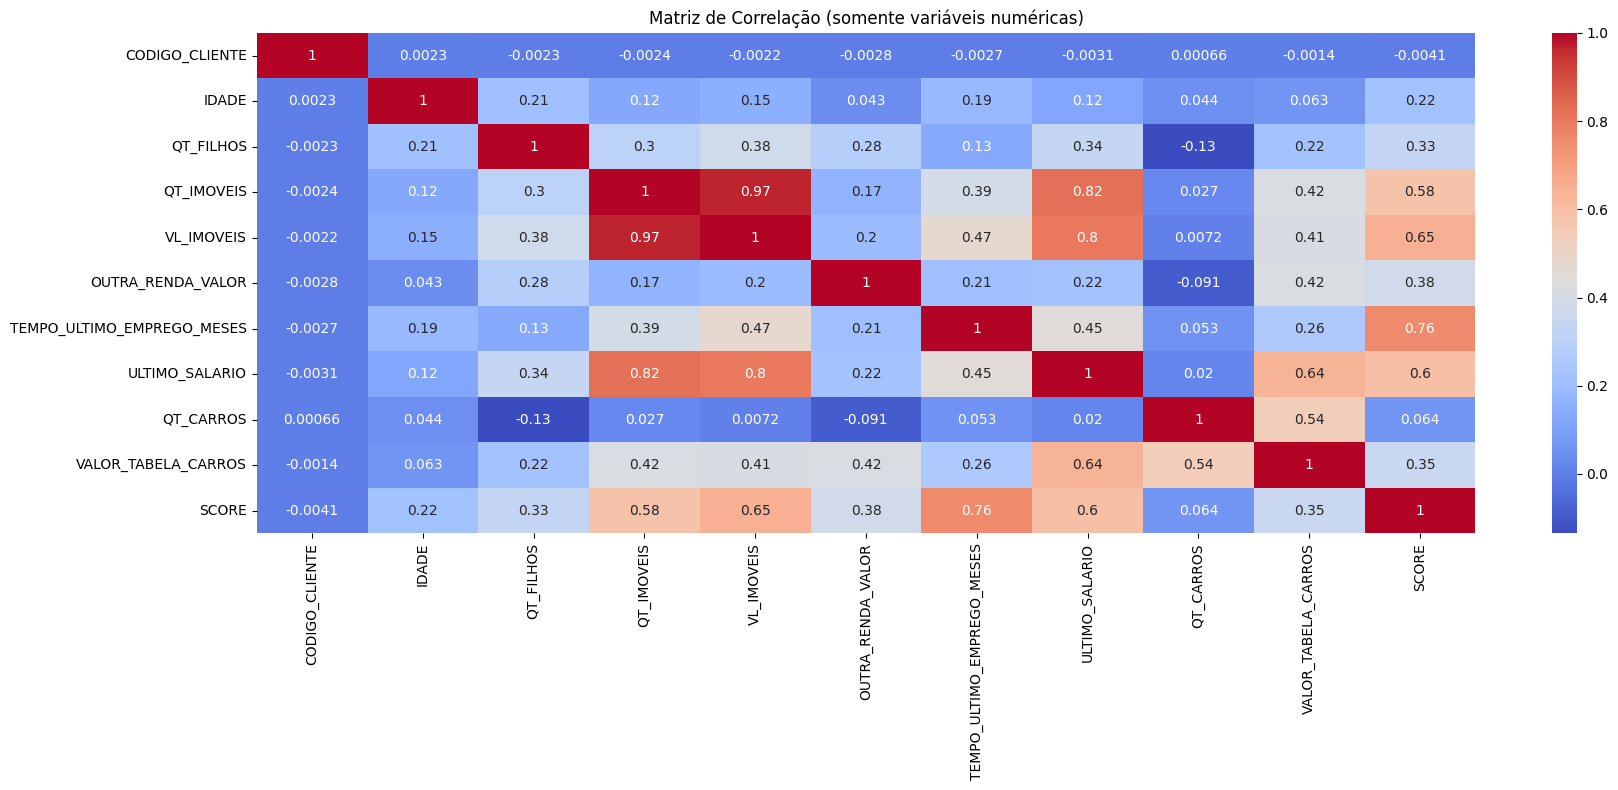

In [21]:
plt.rcParams["figure.figsize"] = (18, 8)

corr = df.select_dtypes(include=[np.number]).corr()

ax = sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação (somente variáveis numéricas)")
plt.show()

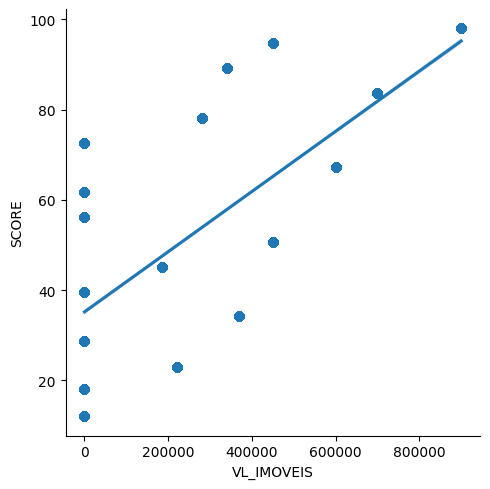

In [22]:

sns.lmplot(x = "VL_IMOVEIS", y = "SCORE", data = df);

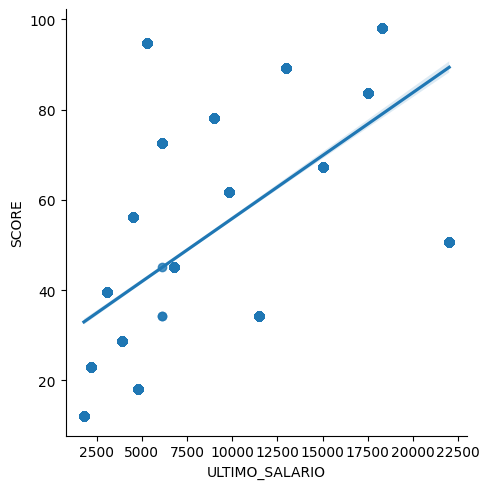

In [23]:

sns.lmplot(x = "ULTIMO_SALARIO", y = "SCORE", data = df);

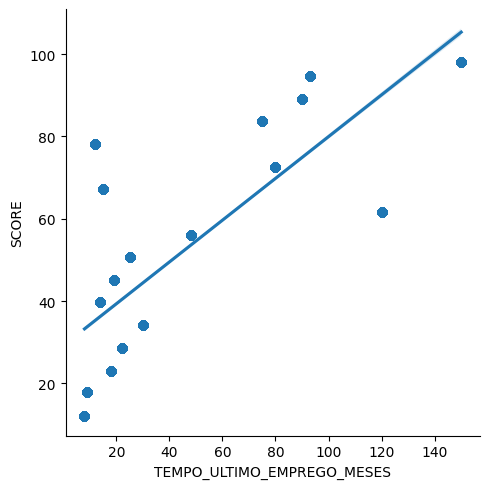

In [24]:

sns.lmplot(x = "TEMPO_ULTIMO_EMPREGO_MESES", y = "SCORE", data = df);

## CRIAÇÃO DE NOVAS DAX

In [25]:
idade_bins = [0, 20, 30, 45, 55, 100]
idade_categoria = ["Até 20", "21 a 30", "31 a 45", "46 a 55", "Maior que 55"]

df["FAIXA_ETARIA"] = pd.cut(df["IDADE"], idade_bins, labels=idade_categoria)
df["FAIXA_ETARIA"].value_counts()

FAIXA_ETARIA
21 a 30         2994
46 a 55         2664
31 a 45         2568
Maior que 55    1692
Até 20           558
Name: count, dtype: int64

In [26]:
df['MAIOR_IDADE'] = np.where(df['IDADE'] >= 18, 'Sim', 'Não')
df["MAIOR_IDADE"].value_counts()

MAIOR_IDADE
Sim    10476
Name: count, dtype: int64

In [27]:
df['TEM_DEPENDENTES'] = np.where(df['QT_FILHOS'] > 0, 'Sim', 'Não')
df["TEM_DEPENDENTES"].value_counts()

TEM_DEPENDENTES
Sim    7147
Não    3329
Name: count, dtype: int64

In [28]:
df['RENDA_TOTAL'] = df['ULTIMO_SALARIO'] + df['OUTRA_RENDA_VALOR']
df['RENDA_TOTAL'].head()

0    1800.0
1    4800.0
2    2200.0
3    3900.0
4    6100.0
Name: RENDA_TOTAL, dtype: float64

In [29]:
df.groupby(['RENDA_TOTAL']).size()

RENDA_TOTAL
1800.0      846
2200.0      792
3100.0      792
3900.0      792
4500.0      468
4800.0      792
6100.0      524
8500.0      522
9000.0      522
9100.0        1
9800.0     1079
11500.0     790
15000.0     522
17000.0     522
17500.0     522
18300.0     522
24400.0     468
dtype: int64

In [30]:
df['CATEGORIA_RENDA'] = pd.cut(
    df['RENDA_TOTAL'],
    bins=[0, 2500, 5000, 10000, 20000, float('inf')],
    labels=['Baixa', 'Média-Baixa', 'Média', 'Média-Alta', 'Alta']
)
df['CATEGORIA_RENDA'].value_counts()

CATEGORIA_RENDA
Média-Alta     2878
Média-Baixa    2844
Média          2648
Baixa          1638
Alta            468
Name: count, dtype: int64

## Pré Processamento dos Dados

In [ ]:
lb = LabelEncoder()

df['FAIXA_ETARIA'] = lb.fit_transform(df['FAIXA_ETARIA'])
df['OUTRA_RENDA'] = lb.fit_transform(df['OUTRA_RENDA'])
df['TRABALHANDO_ATUALMENTE'] = lb.fit_transform(df['TRABALHANDO_ATUALMENTE'])
df['ESTADO_CIVIL'] = lb.fit_transform(df['ESTADO_CIVIL'])
df['CASA_PROPRIA'] = lb.fit_transform(df['CASA_PROPRIA'])
df['ESCOLARIDADE'] = lb.fit_transform(df['ESCOLARIDADE'])
df['UF'] = lb.fit_transform(df['UF'])

df.dropna(inplace = True)

In [ ]:
df.head(5)

In [ ]:
df.info()

In [ ]:
target = df.iloc[:,15:16]

In [ ]:
preditoras = df.copy() 

del preditoras['SCORE'] 

preditoras.head()

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(preditoras, target, test_size = 0.3, random_state = 459)

In [ ]:
sc = MinMaxScaler()
X_treino_normalizados = sc.fit_transform(X_treino)
X_teste_normalizados = sc.transform(X_teste)

## Criar, avaliar e testar nosso modelo preditivo 

In [ ]:
scaler = StandardScaler()
X_treino_normalizados = scaler.fit_transform(X_treino)
X_teste_normalizados = scaler.transform(X_teste)

modelo = LinearRegression(fit_intercept=True)
modelo.fit(X_treino_normalizados, y_treino)

In [ ]:
r2_score(y_teste, modelo.fit(X_treino_normalizados, y_treino).predict(X_teste_normalizados))

In [ ]:
UF = 2
IDADE = 42 
ESCOLARIDADE = 1
ESTADO_CIVIL = 2
QT_FILHOS = 1
CASA_PROPRIA = 1
QT_IMOVEIS = 1
VL_IMOVEIS = 300000
OUTRA_RENDA = 1
OUTRA_RENDA_VALOR = 2000 
TEMPO_ULTIMO_EMPREGO_MESES = 18 
TRABALHANDO_ATUALMENTE = 1
ULTIMO_SALARIO = 5400.0
QT_CARROS = 4
VALOR_TABELA_CARROS = 70000
FAIXA_ETARIA = 3

novos_dados = [UF, IDADE, ESCOLARIDADE, ESTADO_CIVIL, QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,
               OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,
               VALOR_TABELA_CARROS, FAIXA_ETARIA]


X = np.array(novos_dados).reshape(1, -1)
X = sc.transform(X)

print("Score de crédito previsto para esse cliente:", modelo.predict(X))